In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import unicodedata
import re

from collections import Counter                                  

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,                                        
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

from transformers import AutoTokenizer, AutoModel
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
# ============================================================
# 2️⃣ LOAD DATA
# ============================================================
df = pd.read_csv("AFNC_news_dataset_tf-2.csv")
df = df.reset_index(drop=True)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# กำหนด mapping dictionary
label_map = {
    'ข่าวจริง': 'true',
    'ข่าวปลอม': 'fake',
}

In [ ]:
# 1. Clean whitespace and cast to string
df['ประเภทข่าว']     = df['ประเภทข่าว'].astype(str).str.strip()
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].astype(str).str.strip()

# 2. Drop sentinel string values
df = df[~df['ประเภทข่าว'].isin(['nan', 'NaN', '', 'None'])]
df = df[~df['หมวดหมู่ของข่าว'].isin(['nan', 'NaN', '', 'None'])]
df = df.dropna(subset=['หัวข้อข่าว', 'ประเภทข่าว', 'หมวดหมู่ของข่าว']).reset_index(drop=True)

# =======================================================
# 3. Label Encoding  (ข่าวจริง = 0, ข่าวปลอม = 1)
# =======================================================
label2id = {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
id2label = {0: 'ข่าวจริง', 1: 'ข่าวปลอม'}

df['label_id'] = df['ประเภทข่าว'].map(label2id)
df = df.dropna(subset=['label_id']).reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)

df['label_binary'] = df['label_id']

print(f"✅ Label Classes: {label2id}")


✅ Label Classes: {'ข่าวจริง': 0, 'ข่าวปลอม': 1}


In [5]:
# =======================================================
# 4. Thai Text Normalisation
# =======================================================
ZW = ''.join(['\u200B', '\u200C', '\u200D', '\uFEFF'])

def normalize_thai(s):
    if pd.isna(s):
        return None
    s = str(s).replace('\u00A0', ' ').translate({ord(ch): None for ch in ZW})
    s = unicodedata.normalize('NFC', s)
    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r'([\u0E31\u0E34-\u0E3A\u0E47-\u0E4E])\1+', r'\1', s)
    return s

df['ประเภทข่าว']     = df['ประเภทข่าว'].apply(normalize_thai)
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].apply(normalize_thai)

# =======================================================
# 5. Category Encoding
# =======================================================
cats   = sorted(df['หมวดหมู่ของข่าว'].unique())
cat2id = {c: i for i, c in enumerate(cats)}
id2cat = {i: c for c, i in cat2id.items()}

df['category_id'] = df['หมวดหมู่ของข่าว'].map(cat2id)
print(f"✅ Category Classes ({len(cats)} หมวดหมู่)")

✅ Category Classes (8 หมวดหมู่)


In [6]:
# =======================================================
# 6. Balance Dataset
# =======================================================
df_true = df[df['label_id'] == 0]
df_fake = df[df['label_id'] == 1]
print(f"\n📊 Before balance: จริง = {len(df_true)}, ปลอม = {len(df_fake)}")

min_len          = min(len(df_true), len(df_fake))
df_true_sampled  = df_true.sample(n=min_len, random_state=42)
df_fake_sampled  = df_fake.sample(n=min_len, random_state=42)
df_balanced      = pd.concat([df_true_sampled, df_fake_sampled]) \
                     .sample(frac=1, random_state=42).reset_index(drop=True)

print(f"⚖️  After balance (total {len(df_balanced)} news):")
print(df_balanced['ประเภทข่าว'].value_counts())

idx_balanced   = df_balanced.index.values
N_balanced     = len(df_balanced)
y_balanced     = df_balanced['label_id'].values
y_cat_balanced = df_balanced['category_id'].values

print("✅ N_balanced:", N_balanced)


📊 Before balance: จริง = 2872, ปลอม = 8237
⚖️  After balance (total 5744 news):
ประเภทข่าว
ข่าวจริง    2872
ข่าวปลอม    2872
Name: count, dtype: int64
✅ N_balanced: 5744


In [7]:
# =======================================================
# 7. Load WangchanBERTa
# =======================================================
model_WCB  = "airesearch/wangchanberta-base-att-spm-uncased"
tokenizer  = AutoTokenizer.from_pretrained(model_WCB, use_fast=False)
lm_model   = AutoModel.from_pretrained(model_WCB).to(device).eval()

print("\nSample of content:")
print(df_balanced[['หัวข้อข่าว']].head(1))

encoded_inputs = tokenizer(
    df_balanced['หัวข้อข่าว'].tolist(),
    padding=False, truncation=False, return_tensors=None
)
token_lengths = [len(t) for t in encoded_inputs['input_ids']]
print(f"\nAverage tokens: {sum(token_lengths)/len(token_lengths):.2f}")

print("\nSample of true news:")
print(df_balanced[df_balanced['label_id'] == 0][['หัวข้อข่าว', 'label_binary']].head(2))
print("\nSample of fake news:")
print(df_balanced[df_balanced['label_id'] == 1][['หัวข้อข่าว', 'label_binary']].head(2))



Sample of content:
                                          หัวข้อข่าว
0  หลังจากหย่าผู้ชายสามารถจดทะเบียนสมรสต่อได้ทันท...

Average tokens: 21.75

Sample of true news:
                                          หัวข้อข่าว  label_binary
0  หลังจากหย่าผู้ชายสามารถจดทะเบียนสมรสต่อได้ทันท...             0
5  ศูนย์ฉีดวัคซีนกลางบางซื่อ เปิดจองคิวฉีดเข็ม 3 ...             0

Sample of fake news:
                                          หัวข้อข่าว  label_binary
1   ผลิตภัณฑ์ยาแคปซูลกระชาย ช่วยบำรุงหัวใจ และมีฤ...             1
2  PTT ส่ง SMS แจ้งผู้ใช้บริการ ให้แลกคะแนนสะสมผ่...             1


In [8]:
# ====================================================================
# SECTION 5: BERT EMBEDDING FUNCTION
# ====================================================================
@torch.no_grad()
def get_bert_embeddings_batch(
    texts, tokenizer, model, device,
    max_length=256, batch_size=32, use_mean_pool=True
):
    """Returns BERT embeddings as numpy array (N, hidden_size)."""
    model.eval()
    all_embeddings = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]
        batch_texts = [
            "" if (isinstance(t, float) and np.isnan(t)) else str(t)
            for t in batch_texts
        ]
        inputs = tokenizer(
            batch_texts,
            truncation=True, padding=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)

        outputs     = model(**inputs)
        last_hidden = outputs.last_hidden_state          # (B, seq_len, hidden)

        if use_mean_pool:
            attn   = inputs['attention_mask'].unsqueeze(-1)
            summed = (last_hidden * attn).sum(dim=1)
            denom  = attn.sum(dim=1).clamp(min=1)
            emb    = (summed / denom).cpu().numpy()
        else:
            emb = last_hidden[:, 0, :].cpu().numpy()

        all_embeddings.append(emb)

    return np.vstack(all_embeddings)                     # (N, hidden_size)

In [ ]:
# ====================================================================
# SECTION 6: TEMPORAL PREPROCESSING
# ====================================================================
import re
import pandas as pd

def parse_thai_datetime(series):
    thai_months = {
        'ม.ค.': '01', 'ก.พ.': '02', 'มี.ค.': '03', 'เม.ย.': '04',
        'พ.ค.': '05', 'มิ.ย.': '06', 'ก.ค.': '07', 'ส.ค.': '08',
        'ก.ย.': '09', 'ต.ค.': '10', 'พ.ย.': '11', 'ธ.ค.': '12',
        'มกราคม': '01', 'กุมภาพันธ์': '02', 'มีนาคม': '03', 'เมษายน': '04',
        'พฤษภาคม': '05', 'มิถุนายน': '06', 'กรกฎาคม': '07', 'สิงหาคม': '08',
        'กันยายน': '09', 'ตุลาคม': '10', 'พฤศจิกายน': '11', 'ธันวาคม': '12'
    }

    s = series.astype(str).copy()
    s = s.str.replace('น.', '', regex=False).str.replace('เวลา', '', regex=False)

    for th_month, num_month in thai_months.items():
        s = s.str.replace(th_month, f'-{num_month}-', regex=False)

    s = s.apply(lambda x: re.sub(r'\s+', ' ', str(x)).strip())

    # ✅ แปลงปี พ.ศ. → ค.ศ. ใน String ก่อน (regex แทน 4 หลักที่ >= 2401)
    def subtract_543(m):
        year_be = int(m.group(0))
        return str(year_be - 543) if year_be > 2400 else m.group(0)

    s = s.apply(lambda x: re.sub(r'\b(2[4-9]\d{2}|[3-9]\d{3})\b', subtract_543, x))

    # ตอนนี้ปีเป็น ค.ศ. แล้ว → parse ได้ปกติ
    dt = pd.to_datetime(s, dayfirst=True, errors='coerce')

    # Fallback: ใช้ median แทน NaT ที่เหลือ
    median_dt = dt.dropna().median()
    dt = dt.fillna(median_dt)

    return dt

date_col      = 'วันและเวลาที่เผยแพร่'
publish_dates = parse_thai_datetime(df_balanced[date_col])


time_values   = publish_dates.astype('int64').values // 10**9   # Unix seconds

In [10]:
# ====================================================================
# SECTION 7: BERT EMBEDDINGS FOR BALANCED DATASET
# ====================================================================
print("\nSECTION 7: CREATE BERT EMBEDDINGS")

texts_balanced = df_balanced['หัวข้อข่าว'].fillna("").astype(str).tolist()

content_emb = get_bert_embeddings_batch(
    texts_balanced,
    tokenizer=tokenizer, model=lm_model,
    device=device, max_length=256, batch_size=32, use_mean_pool=True
)
x_balanced = normalize(content_emb, axis=1, norm='l2')
print("✅ x_balanced shape:", x_balanced.shape)


SECTION 7: CREATE BERT EMBEDDINGS
✅ x_balanced shape: (5744, 768)



SECTION 8: DATA VISUALISATION


C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2208513301.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


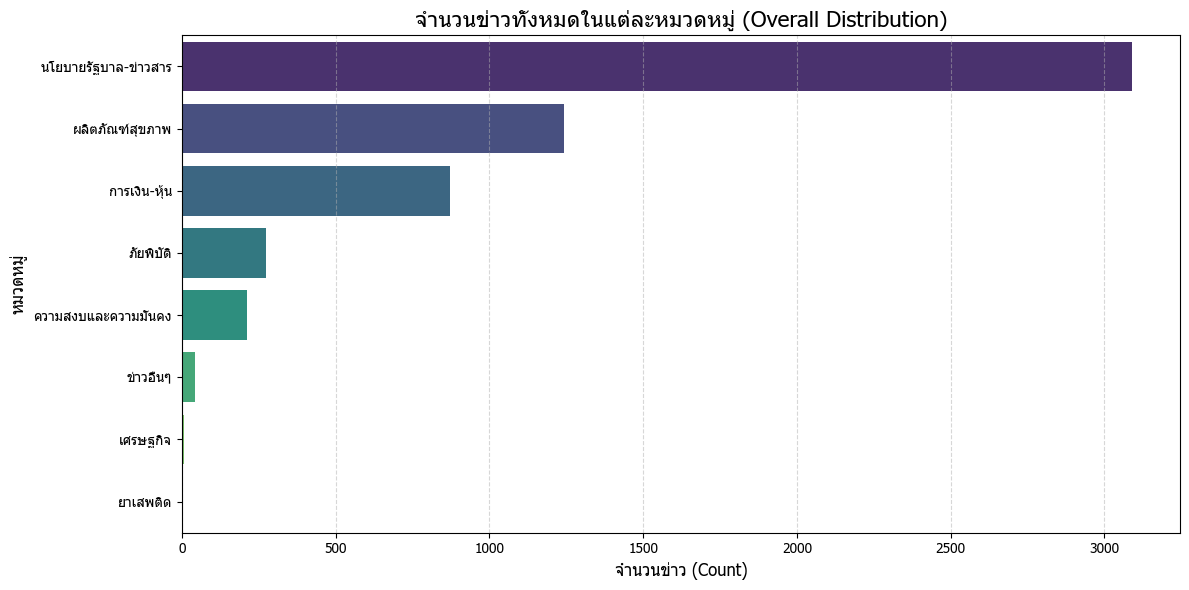

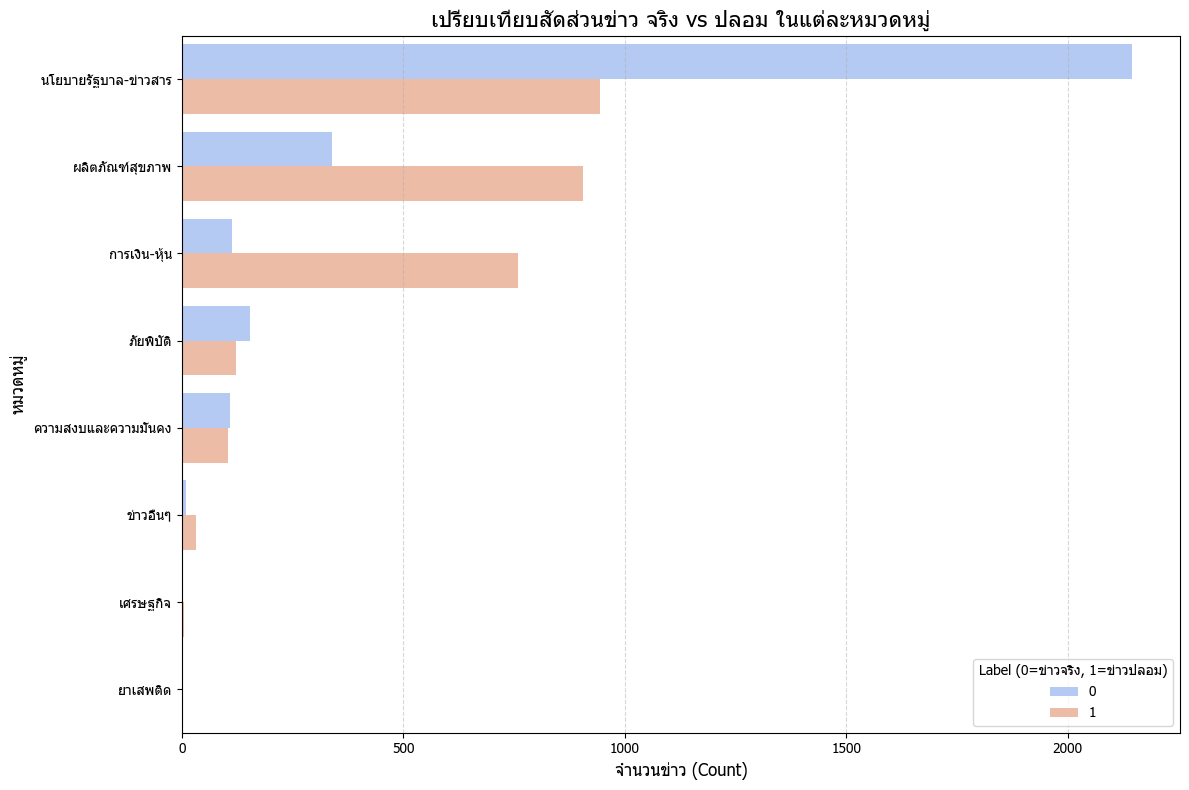

In [11]:
# ====================================================================
# SECTION 8: DATA VISUALISATION
# ====================================================================
print("\nSECTION 8: DATA VISUALISATION")

try:
    plt.rcParams['font.family'] = 'Tahoma'
except Exception:
    pass

col_category = 'หมวดหมู่ของข่าว'
col_label    = 'label_binary'

# Graph 1 — Overall distribution
plt.figure(figsize=(12, 6))
sns.countplot(
    y=df_balanced[col_category],
    order=df_balanced[col_category].value_counts().index,
    palette='viridis'
)
plt.title('จำนวนข่าวทั้งหมดในแต่ละหมวดหมู่ (Overall Distribution)', fontsize=16)
plt.xlabel('จำนวนข่าว (Count)', fontsize=12)
plt.ylabel('หมวดหมู่', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Graph 2 — Real vs Fake per category
plt.figure(figsize=(12, 8))
sns.countplot(
    data=df_balanced,
    y=col_category,
    hue=col_label,
    order=df_balanced[col_category].value_counts().index,
    palette='coolwarm'
)
plt.title('เปรียบเทียบสัดส่วนข่าว จริง vs ปลอม ในแต่ละหมวดหมู่', fontsize=16)
plt.xlabel('จำนวนข่าว (Count)', fontsize=12)
plt.ylabel('หมวดหมู่', fontsize=12)
plt.legend(title='Label (0=ข่าวจริง, 1=ข่าวปลอม)', loc='lower right')  
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [12]:
# ====================================================================
# SECTION 9: BUILD TEMPORAL GRAPH (WangchanBERTa + Time Decay)
# ====================================================================
print("\nSECTION 9: BUILD TEMPORAL GRAPH")

k    = 10
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
nbrs.fit(x_balanced)
distances, indices = nbrs.kneighbors(x_balanced)


edges   = []
weights = []
alpha = 0.00135  # half-life ~512 วัน (เหมาะกับ median ของ data)

for i in range(N_balanced):
    for j_idx in range(1, k + 1):
        j    = indices[i][j_idx]
        sim  = 1 - distances[i][j_idx]
        
        # ✅ หารด้วย 86400 → หน่วยเป็นวัน
        dt_days         = abs(int(time_values[i]) - int(time_values[j])) / 86400
        temporal_weight = np.exp(-alpha * dt_days)
        final_weight    = sim * temporal_weight
        
        edges.append([i, j])
        weights.append(final_weight)

edge_index_st  = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_weight_st = torch.tensor(weights, dtype=torch.float)

print("✅ Temporal Graph Built")
print("   Nodes:", N_balanced)
print("   Edges:", edge_index_st.shape[1])



SECTION 9: BUILD TEMPORAL GRAPH
✅ Temporal Graph Built
   Nodes: 5744
   Edges: 57440


In [13]:
# ====================================================================
# SECTION 10: TRAIN / VAL / TEST SPLIT & DATA OBJECT
# ====================================================================
print("\nSECTION 10: TRAIN/VAL/TEST SPLIT")

x_tensor_st = torch.tensor(x_balanced, dtype=torch.float)
y_tensor_st = torch.tensor(y_balanced,  dtype=torch.long)
idx_all     = np.arange(N_balanced)

idx_train, idx_temp = train_test_split(
    idx_all, test_size=0.30, stratify=y_balanced, random_state=42
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y_balanced[idx_temp], random_state=42
)

train_mask = torch.zeros(N_balanced, dtype=torch.bool); train_mask[idx_train] = True
val_mask   = torch.zeros(N_balanced, dtype=torch.bool); val_mask[idx_val]     = True
test_mask  = torch.zeros(N_balanced, dtype=torch.bool); test_mask[idx_test]   = True

data_st = Data(
    x          = x_tensor_st,
    y          = y_tensor_st,
    edge_index = edge_index_st,
    edge_attr  = edge_weight_st.float(),
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask,
).to(device)

print(f"✅ data_st → Nodes: {data_st.num_nodes}, Edges: {data_st.num_edges}")
print(f"   Train: {train_mask.sum().item()} | Val: {val_mask.sum().item()} | Test: {test_mask.sum().item()}")



SECTION 10: TRAIN/VAL/TEST SPLIT
✅ data_st → Nodes: 5744, Edges: 57440
   Train: 4020 | Val: 862 | Test: 862


In [14]:
from torch_geometric.nn import GATv2Conv

# ====================================================================
# SECTION 11: GAT MODEL DEFINITION (Updated)
# ====================================================================
class GATNet(nn.Module):
    def __init__(self, num_node_features, num_classes,
                 hidden_channels=64, heads=4, dropout_rate=0.4):
        super().__init__()
        self.conv1 = GATv2Conv(
            in_channels=num_node_features, 
            out_channels=hidden_channels, 
            heads=heads, 
            dropout=dropout_rate,
            edge_dim=1
        )
        self.conv2 = GATv2Conv(
            in_channels=hidden_channels * heads, 
            out_channels=num_classes, 
            heads=1, 
            concat=False, 
            dropout=dropout_rate,
            edge_dim=1
        )
        self.dropout_rate = dropout_rate

    def forward(self, data, return_attn=False):
        x, edge_index = data.x, data.edge_index
        edge_weight = getattr(data, 'edge_attr', None)
        if edge_weight is not None:
            edge_weight = edge_weight.view(-1, 1)

        # 🛑 ถ้าต้องการดึง Attention ให้ใส่ return_attention_weights=True
        if return_attn:
            # PyG จะคืนค่าเป็น Tuple: (Node_Features, (Edge_Index, Attention_Weights))
            x, (edge_idx1, attn_weights1) = self.conv1(x, edge_index, edge_attr=edge_weight, return_attention_weights=True)
        else:
            x = self.conv1(x, edge_index, edge_attr=edge_weight)
            
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        if return_attn:
            x, (edge_idx2, attn_weights2) = self.conv2(x, edge_index, edge_attr=edge_weight, return_attention_weights=True)
            # คืนค่าผลทำนาย และ Attention ของทั้ง 2 เลเยอร์
            return x, (edge_idx1, attn_weights1), (edge_idx2, attn_weights2)
        else:
            x = self.conv2(x, edge_index, edge_attr=edge_weight)
            return x

# ====================================================================
# SECTION 12: TRAIN GCN (single canonical training loop)
# ====================================================================
print("\nSECTION 12: TRAIN GCN (Spatio-Temporal Graph)")

model_gnn = GATNet(data_st.num_features, 2, hidden_channels=64, heads=4).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

history      = {'train_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, 201):
    # --- Train ---
    model_gnn.train()
    optimizer.zero_grad()
    out  = model_gnn(data_st)
    loss = criterion(out[data_st.train_mask], data_st.y[data_st.train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred_train = out[data_st.train_mask].argmax(dim=1)
        train_acc  = (pred_train == data_st.y[data_st.train_mask]).float().mean().item()
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)

    # --- Validate ---
    model_gnn.eval()
    with torch.no_grad():
        pred    = model_gnn(data_st).argmax(dim=1)
        val_acc = (pred[data_st.val_mask] == data_st.y[data_st.val_mask]).float().mean().item()
        history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

    if epoch % 20 == 0:
        print(f"   Epoch {epoch:03d}: Loss {loss:.4f} | Train {train_acc:.4f} | Val {val_acc:.4f}")

print(f"\n✅ Training Complete! Best Val Acc: {best_val_acc:.4f}")


SECTION 12: TRAIN GCN (Spatio-Temporal Graph)
   Epoch 020: Loss 0.4872 | Train 0.7903 | Val 0.7749
   Epoch 040: Loss 0.4202 | Train 0.8057 | Val 0.7993
   Epoch 060: Loss 0.3922 | Train 0.8249 | Val 0.8225
   Epoch 080: Loss 0.3803 | Train 0.8284 | Val 0.8434
   Epoch 100: Loss 0.3635 | Train 0.8301 | Val 0.8457
   Epoch 120: Loss 0.3591 | Train 0.8361 | Val 0.8480
   Epoch 140: Loss 0.3553 | Train 0.8410 | Val 0.8445
   Epoch 160: Loss 0.3464 | Train 0.8448 | Val 0.8492
   Epoch 180: Loss 0.3472 | Train 0.8470 | Val 0.8492
   Epoch 200: Loss 0.3428 | Train 0.8440 | Val 0.8480

✅ Training Complete! Best Val Acc: 0.8561


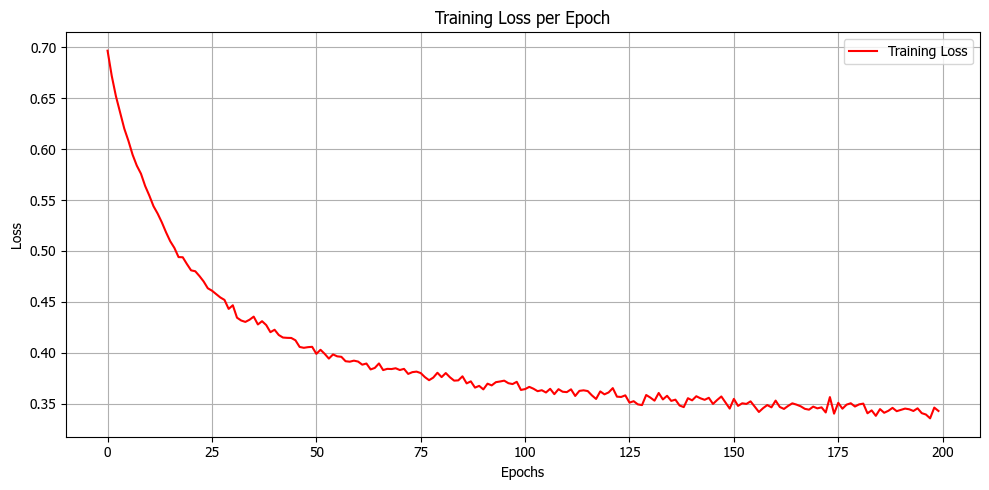

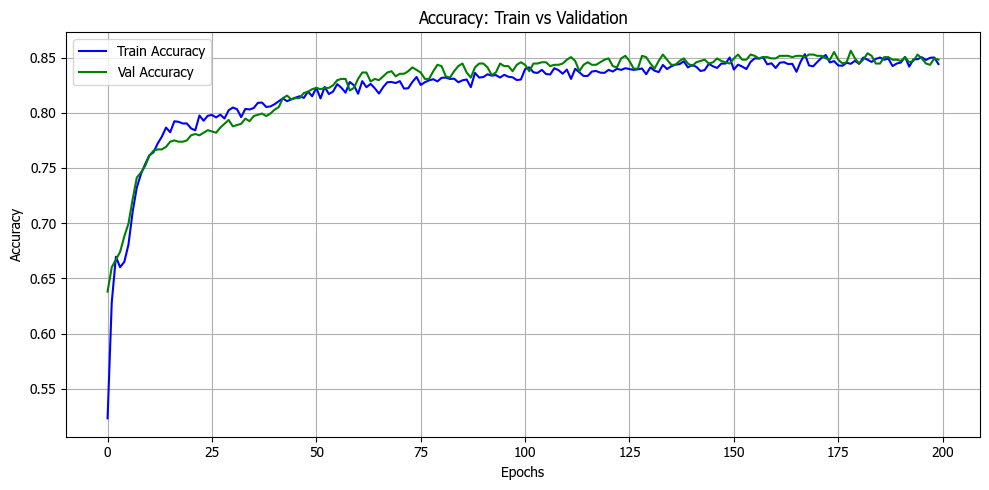

In [15]:
# --- Training plots ---
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss', color='red')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history['val_acc'],   label='Val Accuracy',   color='green')
plt.title('Accuracy: Train vs Validation')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [16]:
# ====================================================================
# SECTION 13: PREDICT FUNCTION
# ====================================================================
def predict_news(
    content, topn=10,
    x_np=None, label2id=None, id2label=None,
    y_cat_np=None, id2cat=None,
    device=None, nbrs=None, model_gnn=None, embed_fn=None
):
    if embed_fn is None:
        raise ValueError("Missing 'embed_fn'.")

    # 1. Embedding
    emb_batch   = embed_fn([content])
    content_emb = emb_batch[0]
    emb         = normalize(content_emb.reshape(1, -1), axis=1, norm='l2')[0]

    # 2. kNN search
    dists, idxs = nbrs.kneighbors(emb.reshape(1, -1), n_neighbors=topn)
    idxs        = idxs[0]

    # 3. Category prediction (majority vote)
    pred_category = "ไม่ระบุ"
    neighbor_cats = []
    if y_cat_np is not None and id2cat is not None:
        try:
            neighbor_cats = [id2cat[cid] for cid in y_cat_np[idxs]]
            most_common   = Counter(neighbor_cats).most_common(1)   
            if most_common:
                pred_category = most_common[0][0]
        except Exception as e:
            print(f"⚠️ Category Warning: {e}")

    # 4. Build star graph for GCN
    X_new     = np.vstack([emb, x_np[idxs]])
    center    = 0
    neighbors = np.arange(1, topn + 1)

    edge_index_new = np.concatenate([
        np.stack([np.full(topn, center), neighbors]),
        np.stack([neighbors, np.full(topn, center)])
    ], axis=1)
    edge_weight_new = np.concatenate([1 - dists[0], 1 - dists[0]])

    data_new = Data(
        x          = torch.tensor(X_new,           dtype=torch.float, device=device),
        edge_index = torch.tensor(edge_index_new,  dtype=torch.long,  device=device),
        edge_attr = torch.tensor(edge_weight_new, dtype=torch.float, device=device).view(-1, 1),
    )

    # 5. Predict พร้อมดึง Attention Weights
    model_gnn.eval()
    with torch.no_grad():
        # เรียกโหมด return_attn=True
        logits, attn1, attn2 = model_gnn(data_new, return_attn=True)
        probas  = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_id = int(np.argmax(probas))

        # --- ส่วนดึง Attention (Layer 2) ---
        edge_idx_l2, attn_w_l2 = attn2
        edge_idx_l2 = edge_idx_l2.cpu().numpy()
        attn_w_l2 = attn_w_l2.cpu().numpy().flatten()
        
        # เราสนใจเฉพาะเส้นเชื่อมที่พุ่งเข้าหาโหนดศูนย์กลาง (target node id = 0)
        # edge_index จะมีโครงสร้างเป็น [source_nodes, target_nodes]
        target_nodes = edge_idx_l2[1, :] 
        mask_to_center = (target_nodes == 0)
        
        # ดึง ID ของโหนดต้นทาง และน้ำหนัก Attention ที่ส่งมาให้โหนด 0
        source_nodes = edge_idx_l2[0, :][mask_to_center]
        attention_to_center = attn_w_l2[mask_to_center]

        # นำมาจับคู่เรียงลำดับความสำคัญ (หาว่าเพื่อนบ้านคนไหนมีอิทธิพลสูงสุด)
        neighbor_attentions = []
        # source_node จะเป็น index 1 ถึง topn (เพราะ 0 คือตัวเอง)
        for src, weight in zip(source_nodes, attention_to_center):
            if src == 0: continue # ข้าม self-loop (โยงหาตัวเอง)
            
            real_db_idx = idxs[src - 1] # แปลงกลับเป็น index ในฐานข้อมูลหลัก
            neighbor_attentions.append({
                'db_index': real_db_idx,
                'weight': float(weight),
                'category': id2cat[y_cat_np[real_db_idx]] if y_cat_np is not None else "ไม่ระบุ"
            })
        
        # เรียงลำดับจากน้ำหนักมากไปน้อย
        neighbor_attentions = sorted(neighbor_attentions, key=lambda x: x['weight'], reverse=True)

    return {
        'label':         id2label[pred_id],
        'probability':   float(probas[pred_id]),
        'pred_id':       pred_id,
        'category':      pred_category,
        'attention_explain': neighbor_attentions # <--- ได้ข้อมูล Explainable กลับไปใช้งาน
    }


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

def plot_attention_explanation(target_text, pred_label, attention_list, df_original, id2label, top_k=5):
    """
    ฟังก์ชันสำหรับพล็อตกราฟแท่งแสดง Attention Weights ของ GAT
    
    Parameters:
    - target_text: ข้อความข่าวที่เรากำลังทำนาย (ข่าวใหม่)
    - pred_label: ผลลัพธ์ที่โมเดลทำนายได้ (เช่น 'ข่าวปลอม')
    - attention_list: ลิสต์ของดิกชันนารี attention_explain ที่ได้จากฟังก์ชัน predict_news
    - df_original: DataFrame ต้นฉบับ (df_balanced) เพื่อดึงข้อความข่าวอ้างอิงและ Label จริง
    - id2label: Dictionary แปลง id เป็นชื่อ label (เช่น {0: 'ข่าวจริง', 1: 'ข่าวปลอม'})
    - top_k: จำนวนเพื่อนบ้านที่ต้องการแสดงบนกราฟ (ค่าเริ่มต้น 5 โหนดที่อิทธิพลสูงสุด)
    """
    
    # ตั้งค่าฟอนต์ภาษาไทย (เหมือนที่คุณทำไว้ใน Section 8)
    try:
        plt.rcParams['font.family'] = 'Tahoma' 
    except Exception:
        pass

    # ดึงข้อมูลเพื่อนบ้าน Top-K
    top_neighbors = attention_list[:top_k]
    
    texts = []
    weights = []
    colors = []
    labels = []
    
    # กำหนดสี: ข่าวปลอม = แดง, ข่าวจริง = เขียว
    color_map = {'ข่าวปลอม': '#e74c3c', 'ข่าวจริง': '#2ecc71'}

    for n in top_neighbors:
        idx = n['db_index']
        weight = n['weight'] * 100  # แปลงเป็นเปอร์เซ็นต์
        
        # ดึงข้อความและ Label จริงจาก DataFrame ต้นฉบับ
        ref_text = df_original.iloc[idx]['หัวข้อข่าว']
        ref_label_id = df_original.iloc[idx]['label_id']
        ref_label_name = id2label[ref_label_id]
        
        # ตัดข้อความให้ยาวไม่เกิน 50 ตัวอักษร แล้วใส่ '...' (เพื่อไม่ให้แกน Y กว้างเกินไป)
        short_text = textwrap.shorten(ref_text, width=50, placeholder="...")
        
        texts.append(f"[{ref_label_name}]\n{short_text}")
        weights.append(weight)
        colors.append(color_map[ref_label_name])
        labels.append(ref_label_name)

    # สร้างกราฟ
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(texts, weights, color=colors, edgecolor='black', alpha=0.8)
    
    # ตกแต่งกราฟ
    ax.invert_yaxis()  # ให้น้ำหนักมากสุดอยู่ด้านบน
    ax.set_xlabel('Attention Weight (อิทธิพลที่ส่งผลต่อการทำนาย) (%)', fontsize=12)
    ax.set_title(f"คำทำนาย: {pred_label}\nข่าวเป้าหมาย: {textwrap.shorten(target_text, width=70)}", 
                 fontsize=14, fontweight='bold', pad=15)
    
    # ใส่ตัวเลข % ไว้ท้ายแท่งกราฟ
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', 
                ha='left', va='center', fontweight='bold', fontsize=11)

    # ปรับแกน X ให้มีพื้นที่เหลือสำหรับตัวเลข
    ax.set_xlim(0, max(weights) + 15) 
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Custom Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map['ข่าวจริง'], edgecolor='black', label='ข่าวอ้างอิง: จริง'),
                       Patch(facecolor=color_map['ข่าวปลอม'], edgecolor='black', label='ข่าวอ้างอิง: ปลอม')]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    plt.show()

In [17]:
# ====================================================================
# PART 1 — Evaluate GCN on Test Set
# ====================================================================
print("\n" + "="*80)
print("PART 1: GCN EVALUATION ON TEST SET")
print("="*80)

model_gnn.eval()
with torch.no_grad():
    final_out_gcn = model_gnn(data_st)
    y_true_gcn    = data_st.y[data_st.test_mask].cpu().numpy()
    y_pred_gcn    = final_out_gcn[data_st.test_mask].argmax(dim=1).cpu().numpy()

acc       = accuracy_score(y_true_gcn, y_pred_gcn)
precision = precision_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
recall    = recall_score(y_true_gcn,    y_pred_gcn, average='weighted', zero_division=0)
f1        = f1_score(y_true_gcn,        y_pred_gcn, average='weighted', zero_division=0)

results_gcn = {
    "Accuracy":           float(acc),
    "Precision_weighted": float(precision),
    "Recall_weighted":    float(recall),
    "F1_weighted":        float(f1),
}

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_true_gcn, y_pred_gcn, digits=4))



PART 1: GCN EVALUATION ON TEST SET
Accuracy : 0.8596
Precision: 0.8603
Recall   : 0.8596
F1-score : 0.8596

Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.8762    0.8376    0.8565       431
           1     0.8444    0.8817    0.8627       431

    accuracy                         0.8596       862
   macro avg     0.8603    0.8596    0.8596       862
weighted avg     0.8603    0.8596    0.8596       862



In [18]:
# ====================================================================
# PART 2 — Predict New News Samples
# ====================================================================
print("\n" + "="*80)
print("PART 2: PREDICT NEW NEWS SAMPLES")
print("="*80)

test_news_data = [
    # ข่าวจริง (Label 0)
    {"content": "ททท. เปิดตัว 'ลิซ่า' เป็นตัวแทนการท่องเที่ยวไทย Amazing Thailand Ambassador", "label_true": 0},
    {"content": "สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล' หลังพังถล่มจากฝนตกหนัก",  "label_true": 0},
    {"content": "บขส. เปิดให้บริการเดินรถโดยสาร เส้นทาง ขอนแก่น – นครหลวงเวียงจันทน์",          "label_true": 0},
    {"content": "อุทยานฯ เขาพนมเบญจา ชวนนักท่องเที่ยว ตามรอยจูราสสิค เวิลด์",                    "label_true": 0},
    {"content": "พบอิฐโบราณชิ้นสำคัญ หลักฐานทางประวัติศาสตร์ที่เก่าแก่ของเชียงราย",              "label_true": 0},
    {"content": "ปิดเทอม สวนสัตว์เปิดเขาเขียว เผยโฉม 'ลูกสมเสร็จตัวล่าสุด'",                    "label_true": 0},
    {"content": "อาการเจ็บหน้าอก สัญญาณอันตรายที่ไม่ควรมองข้าม",                                "label_true": 0},
    {"content": "กกล.บูรพา จับกุมแรงงานกัมพูชา 11 คน ลักลอบข้ามชายแดนสระแก้ว",                  "label_true": 0},
    {"content": "ททท.คาด 'เทศกาลกินผักภูเก็ต 2568' รายได้ทะลุ 22,000 ล้านบาท",                   "label_true": 0},
    {"content": "'ข้าวต้ม' ฟื้นตัวดี ถีบตัวลุกได้ ทีมแพทย์ช่วยกายภาพต่อเนื่อง",                 "label_true": 0},
    # ข่าวปลอม (Label 1)
    {"content": "ด่วน! สะพานกรุงเทพถล่ม มีผู้เสียชีวิต 36 ราย",                                  "label_true": 1},
    {"content": "กระทรวงยุติธรรม ร่วมกับ ตำรวจไซเบอร์ เปิดให้ลงทะเบียนยื่นหลักฐาน เพื่อรับเงินคืนจากมิจฉาชีพ", "label_true": 1},
    {"content": "การดื่มน้ำมะนาวสามารถทำลายมะเร็งเนื้อร้ายที่รุนแรงได้",                         "label_true": 1},
    {"content": "ผู้สูงอายุ 60 ปีขึ้นไป รับเงินอุดหนุนพิเศษ 3,000 บาท ไม่ต้องลงทะเบียน",        "label_true": 1},
    {"content": "กรมการขนส่งเปิดทำใบขับขี่ออนไลน์ ผ่านเพจเฟซบุ๊ก Pages DTL Noline",              "label_true": 1},
    {"content": "กินถั่วลิสงวันละ 1 กำมือ ช่วยรักษาอาการวัยทอง อารมณ์แปรปรวน",                  "label_true": 1},
    {"content": "กฟภ. เปิดช่องทางติดต่อด่วน ทางไลน์ไอดี 'pea9394'",                              "label_true": 1},
    {"content": "สินเชื่อด่วนออมสิน สมัครง่าย ไม่ต้องใช้เอกสาร ติดต่อได้ที่เพจ Ulises Elizabeth Love", "label_true": 1},
    {"content": "รองแม่ทัพภาคที่ 2 ถูกตำหนิ เหตุรับเงินบริจาควัด",                               "label_true": 1},
    {"content": "วางก้อนน้ำแข็งบนท้ายทอย ช่วยรักษาโรคทางเดินหายใจ โรคหลอดเลือดหัวใจ และอาการปวดเมื่อยตามร่างกาย", "label_true": 1},
]

k            = 10
current_nbrs = NearestNeighbors(n_neighbors=k, metric='cosine').fit(x_balanced)
my_embed_fn  = lambda texts: get_bert_embeddings_batch(
    texts, tokenizer=tokenizer, model=lm_model, device=device
)

y_true_part2 = []
y_pred_part2 = []

print("-" * 80)
for i, news in enumerate(test_news_data):
    try:
        result  = predict_news(
            content=news['content'], topn=k,
            x_np=x_balanced, nbrs=current_nbrs,
            label2id=label2id, id2label=id2label,
            y_cat_np=y_cat_balanced, id2cat=id2cat,
            device=device, model_gnn=model_gnn, embed_fn=my_embed_fn
        )
        pred_id = result['pred_id']
        y_true_part2.append(news["label_true"])
        y_pred_part2.append(pred_id)

        status = "✅" if pred_id == news["label_true"] else "❌"
       # ปริ้นท์แค่รอบเดียวพอครับ
        print(f"[{status}] {news['content'][:55]}...")
        print(f"    TRUE: {id2label[news['label_true']]} | PRED: {result['label']} | Prob: {result['probability']:.3f}")
        print(f"    หมวดหมู่: {result['category']}")
        print("-" * 50)
        
        # 🌟 พล็อตกราฟ Attention สำหรับข่าวที่ 0 และ 10
        if i in [0, 10]:  
            plot_attention_explanation(
                target_text=news['content'],
                pred_label=result['label'],
                attention_list=result['attention_explain'], # ดึงมาจาก predict_news ที่อัปเดตแล้ว
                df_original=df_balanced, 
                id2label=id2label,
                top_k=5
            )
    except Exception as e:
        print(f"Error sample {i}: {e}")


if y_pred_part2:
    cm   = confusion_matrix(y_true_part2, y_pred_part2)     
    acc  = accuracy_score(y_true_part2, y_pred_part2)
    prec = precision_score(y_true_part2, y_pred_part2, zero_division=0)
    rec  = recall_score(y_true_part2,   y_pred_part2, zero_division=0)
    f1_s = f1_score(y_true_part2,       y_pred_part2, zero_division=0)

    print("\n" + "="*60)
    print("PART 2 SUMMARY")
    print("="*60)
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1_s:.4f}")
    print(classification_report(
        y_true_part2, y_pred_part2,
        target_names=[id2label[0], id2label[1]], zero_division=0
    ))


PART 2: PREDICT NEW NEWS SAMPLES
--------------------------------------------------------------------------------
[✅] ททท. เปิดตัว 'ลิซ่า' เป็นตัวแทนการท่องเที่ยวไทย Amazing...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.507
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
Error sample 0: name 'plot_attention_explanation' is not defined
[✅] สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล' หลัง...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.949
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
[✅] บขส. เปิดให้บริการเดินรถโดยสาร เส้นทาง ขอนแก่น – นครหลว...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.797
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
[✅] อุทยานฯ เขาพนมเบญจา ชวนนักท่องเที่ยว ตามรอยจูราสสิค เวิ...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.996
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
[❌] พบอิฐโบราณชิ้นสำคัญ 


PART 3: BASELINE MODELS COMPARISON

🔄 Baseline 1: TF-IDF + Logistic Regression...


c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


✅ Done

🔄 Baseline 2: WangchanBERTa + Random Forest...
✅ Done

🔄 Baseline 3: XLM-RoBERTa + Logistic Regression...
✅ Done

📊 MODEL COMPARISON RESULTS
                         Accuracy  Precision_weighted  Recall_weighted  \
1. GCN (Wangchan+Graph)    0.8596              0.8603           0.8596   
2. TF-IDF + LR             0.9269              0.9304           0.9269   
3. WangchanBERTa + RF      0.8608              0.8623           0.8608   
4. XLM-RoBERTa + LR        0.8155              0.8158           0.8155   

                         F1_weighted  
1. GCN (Wangchan+Graph)       0.8596  
2. TF-IDF + LR                0.9268  
3. WangchanBERTa + RF         0.8606  
4. XLM-RoBERTa + LR           0.8155  


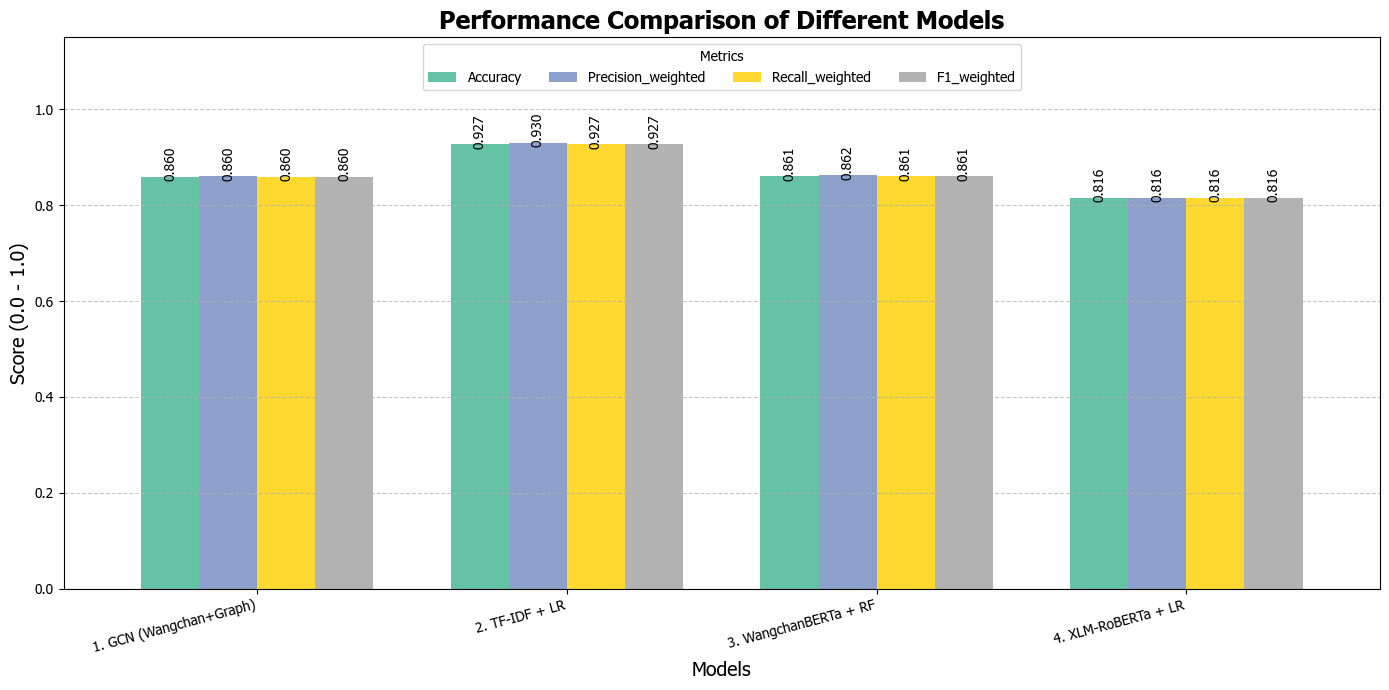

In [19]:
# ====================================================================
# PART 3 — Baseline Models Comparison
# ====================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from pythainlp.tokenize import word_tokenize

print("\n" + "="*80)
print("PART 3: BASELINE MODELS COMPARISON")
print("="*80)

texts_balanced = df_balanced['หัวข้อข่าว'].astype(str).tolist()

y_train_base = y_balanced[idx_train]
y_test_base  = y_balanced[idx_test]
train_texts  = [texts_balanced[i] for i in idx_train]
test_texts   = [texts_balanced[i] for i in idx_test]

results_comparison = {}
results_comparison['1. GCN (Wangchan+Graph)'] = results_gcn

# --- Baseline 1: TF-IDF + LR ---
print("\n🔄 Baseline 1: TF-IDF + Logistic Regression...")

def thai_tokenizer(text):
    return word_tokenize(text, engine='newmm', keep_whitespace=False)

tfidf         = TfidfVectorizer(tokenizer=thai_tokenizer, max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf  = tfidf.transform(test_texts)

clf_tfidf    = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train_base)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

results_comparison['2. TF-IDF + LR'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_tfidf),
    "Precision_weighted": precision_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base,    y_pred_tfidf, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base,        y_pred_tfidf, average='weighted', zero_division=0),
}
print("✅ Done")

# --- Baseline 2: WangchanBERTa + RF ---
print("\n🔄 Baseline 2: WangchanBERTa + Random Forest...")

X_train_wcb   = x_balanced[idx_train]
X_test_wcb    = x_balanced[idx_test]
clf_rf        = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_train_wcb, y_train_base)
y_pred_wcb_rf = clf_rf.predict(X_test_wcb)

results_comparison['3. WangchanBERTa + RF'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_wcb_rf),
    "Precision_weighted": precision_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base,    y_pred_wcb_rf, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base,        y_pred_wcb_rf, average='weighted', zero_division=0),
}
print("✅ Done")

# --- Baseline 3: XLM-RoBERTa + LR ---
print("\n🔄 Baseline 3: XLM-RoBERTa + Logistic Regression...")

model_xlm_name = "xlm-roberta-base"
tokenizer_xlm  = AutoTokenizer.from_pretrained(model_xlm_name)
model_xlm      = AutoModel.from_pretrained(model_xlm_name).to(device).eval()

xlm_emb      = get_bert_embeddings_batch(
    texts_balanced, tokenizer=tokenizer_xlm, model=model_xlm,
    device=device, max_length=256, batch_size=32, use_mean_pool=True
)
xlm_emb_norm = normalize(xlm_emb, axis=1, norm='l2')

X_train_xlm = xlm_emb_norm[idx_train]
X_test_xlm  = xlm_emb_norm[idx_test]

clf_xlm    = LogisticRegression(max_iter=1000, random_state=42)
clf_xlm.fit(X_train_xlm, y_train_base)
y_pred_xlm = clf_xlm.predict(X_test_xlm)

results_comparison['4. XLM-RoBERTa + LR'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_xlm),
    "Precision_weighted": precision_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base,    y_pred_xlm, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base,        y_pred_xlm, average='weighted', zero_division=0),
}
print("✅ Done")

# --- Comparison table & chart ---
print("\n" + "="*80)
print("📊 MODEL COMPARISON RESULTS")
print("="*80)

df_results = pd.DataFrame(results_comparison).T
df_results = df_results[['Accuracy', 'Precision_weighted', 'Recall_weighted', 'F1_weighted']]
print(df_results.round(4))

fig, ax = plt.subplots(figsize=(14, 7))
df_results.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Performance Comparison of Different Models', fontsize=18, fontweight='bold')
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Score (0.0 - 1.0)', fontsize=14)
ax.set_ylim(0, 1.15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Metrics', loc='upper center', ncol=4)
ax.grid(axis='y', linestyle='--', alpha=0.7)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontsize=10, rotation=90)
plt.tight_layout()
plt.show()



PART 4: CONFUSION MATRICES


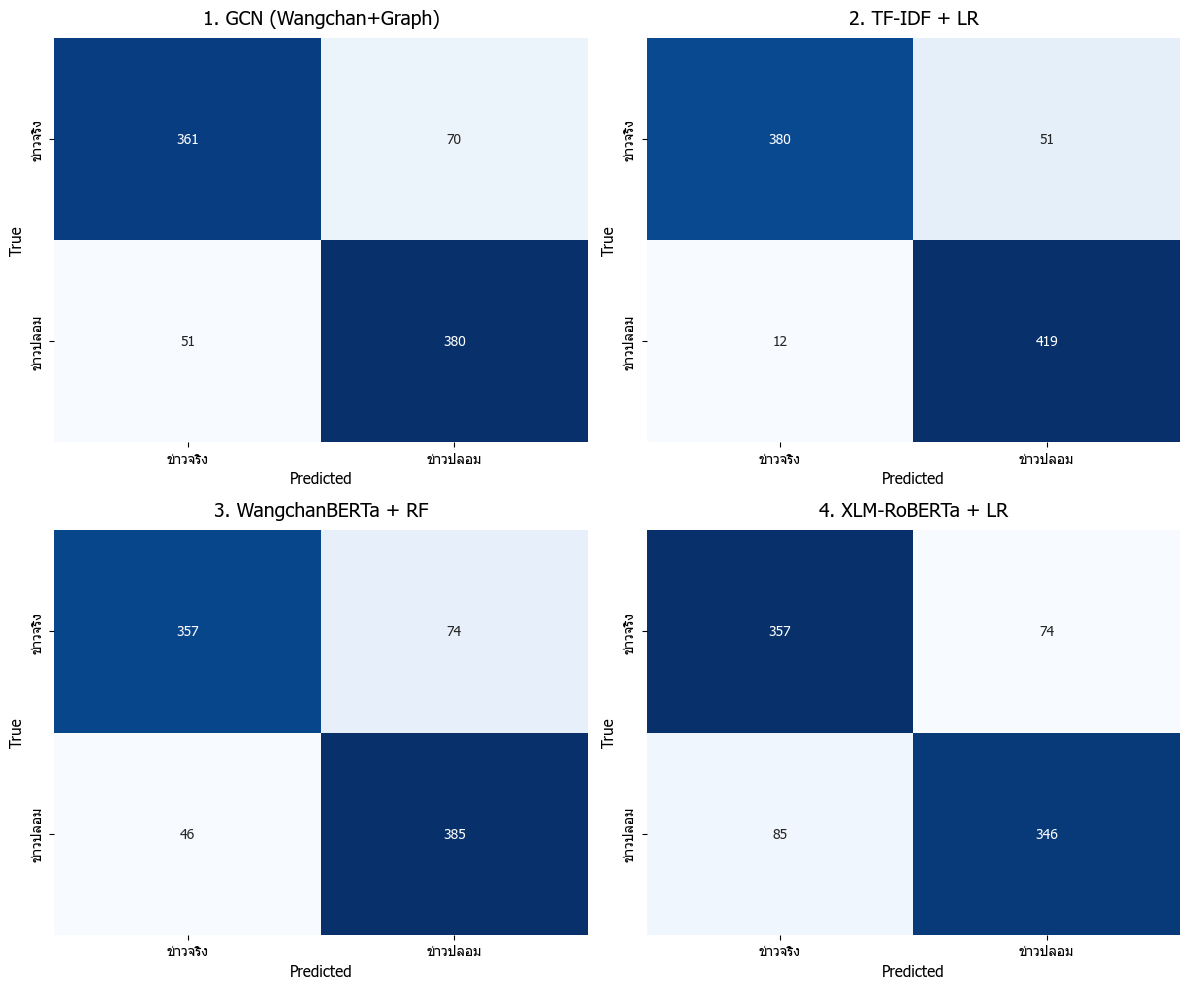

In [20]:
# ====================================================================
# PART 4 — Confusion Matrices (All Models)
# ====================================================================
print("\n" + "="*80)
print("PART 4: CONFUSION MATRICES")
print("="*80)

class_names       = [id2label[0], id2label[1]]
model_predictions = [
    ("1. GCN (Wangchan+Graph)", y_true_gcn,  y_pred_gcn),
    ("2. TF-IDF + LR",          y_test_base, y_pred_tfidf),
    ("3. WangchanBERTa + RF",   y_test_base, y_pred_wcb_rf),
    ("4. XLM-RoBERTa + LR",    y_test_base, y_pred_xlm),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (mname, yt, yp) in enumerate(model_predictions):
    cm = confusion_matrix(yt, yp)                              
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[i].set_title(mname, fontsize=14, pad=10)
    axes[i].set_xlabel('Predicted', fontsize=11)
    axes[i].set_ylabel('True', fontsize=11)
plt.tight_layout()
plt.show()


In [21]:
# ====================================================================
# PART 5 — Error Analysis: GCN Misclassified News
# ====================================================================
print("\n" + "="*80)
print("🚨 ERROR ANALYSIS: ข่าวที่โมเดล GCN ทายผิดพลาด (Test Set)")
print("="*80)

test_indices = np.where(data_st.test_mask.cpu().numpy())[0]
texts_test   = [texts_balanced[i] for i in test_indices]

misclassified_samples = []
for i in range(len(y_true_gcn)):
    true_label = y_true_gcn[i]
    pred_label = y_pred_gcn[i]
    if true_label != pred_label:
        error_type = (
            "False Positive (หลงผิดคิดว่าปลอม)"
            if pred_label == 1
            else "False Negative (โดนหลอกคิดว่าจริง)"
        )
        misclassified_samples.append({
            'text':            texts_test[i],
            'true_label_text': id2label[true_label],
            'pred_label_text': id2label[pred_label],
            'error_type':      error_type,
        })

total_errors = len(misclassified_samples)
num_to_show  = 20
print(f"พบข่าวที่ทายผิดทั้งหมด {total_errors} ข่าว (จาก {len(y_true_gcn)} ข่าวในชุดทดสอบ)")
print(f"กำลังแสดงตัวอย่าง {min(num_to_show, total_errors)} ข่าวแรก:\n")

for idx, item in enumerate(misclassified_samples[:num_to_show]):
    print(f"[{idx+1}] ❌ {item['error_type']}")
    print(f"เนื้อหาข่าว : {item['text']}")
    print(f"ค่าจริง (True) : {item['true_label_text']} | ทำนาย (Pred) : {item['pred_label_text']}")
    print("-" * 70)


🚨 ERROR ANALYSIS: ข่าวที่โมเดล GCN ทายผิดพลาด (Test Set)
พบข่าวที่ทายผิดทั้งหมด 121 ข่าว (จาก 862 ข่าวในชุดทดสอบ)
กำลังแสดงตัวอย่าง 20 ข่าวแรก:

[1] ❌ False Negative (โดนหลอกคิดว่าจริง)
เนื้อหาข่าว :  รถโดยสารประจำทางที่ใช้ป้ายวิ่งด้วยระบบไฟฟ้าถือว่าผิดกฎหมาย
ค่าจริง (True) : ข่าวปลอม | ทำนาย (Pred) : ข่าวจริง
----------------------------------------------------------------------
[2] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหาข่าว : กทม. ประกาศสิ้นสุดสาธารณภัยในเขตพื้นที่ก่อสร้างอาคาร สตง.
ค่าจริง (True) : ข่าวจริง | ทำนาย (Pred) : ข่าวปลอม
----------------------------------------------------------------------
[3] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหาข่าว : พื้นที่บ้านหนองจาน จ.สระแก้ว อยู่ในเขตประเทศไทย
ค่าจริง (True) : ข่าวจริง | ทำนาย (Pred) : ข่าวปลอม
----------------------------------------------------------------------
[4] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหาข่าว : 10 ผักพื้นบ้าน ช่วยบำรุงสมอง ชะลอความแก่ จริงหรือ?
ค่าจริง (True) : ข่าวจริง | ทำนาย (Pred) : ข่าวปลอม


📊 KEYWORD ANALYSIS: คำศัพท์ที่มักทำให้โมเดลทายผิด
📌 Top 15 คำ — False Positives (ข่าวจริงที่โมเดลคิดว่าปลอม):
   - ไทย: 8 ครั้ง
   - พื้นที่: 6 ครั้ง
   - กิน: 5 ครั้ง
   - เสี่ยง: 5 ครั้ง
   - แจ้ง: 4 ครั้ง
   - อาการ: 4 ครั้ง
   - ปี: 4 ครั้ง
   - กทม.: 3 ครั้ง
   - บ้าน: 3 ครั้ง
   - เตรียม: 3 ครั้ง
   - น้ำท่วม: 3 ครั้ง
   - ดื่ม: 3 ครั้ง
   - โรค: 3 ครั้ง
   - ออนไลน์: 3 ครั้ง
   - 68: 3 ครั้ง

📌 Top 15 คำ — False Negatives (ข่าวปลอมที่โมเดลคิดว่าจริง):
   - ไทย: 7 ครั้ง
   - บาท: 7 ครั้ง
   - วันที่: 6 ครั้ง
   - แจ้ง: 5 ครั้ง
   - 19: 5 ครั้ง
   - ประเทศ: 4 ครั้ง
   - โควิด: 4 ครั้ง
   - ปตท.: 4 ครั้ง
   - บริษัท: 4 ครั้ง
   - จ.: 4 ครั้ง
   - ทำ: 3 ครั้ง
   - รัฐ: 3 ครั้ง
   - แจก: 3 ครั้ง
   - เงิน: 3 ครั้ง
   - 67: 3 ครั้ง


C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\3627716954.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_fp), y=list(words_fp), ax=axes[0], palette='Reds_r')
C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\3627716954.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_fn), y=list(words_fn), ax=axes[1], palette='Oranges_r')


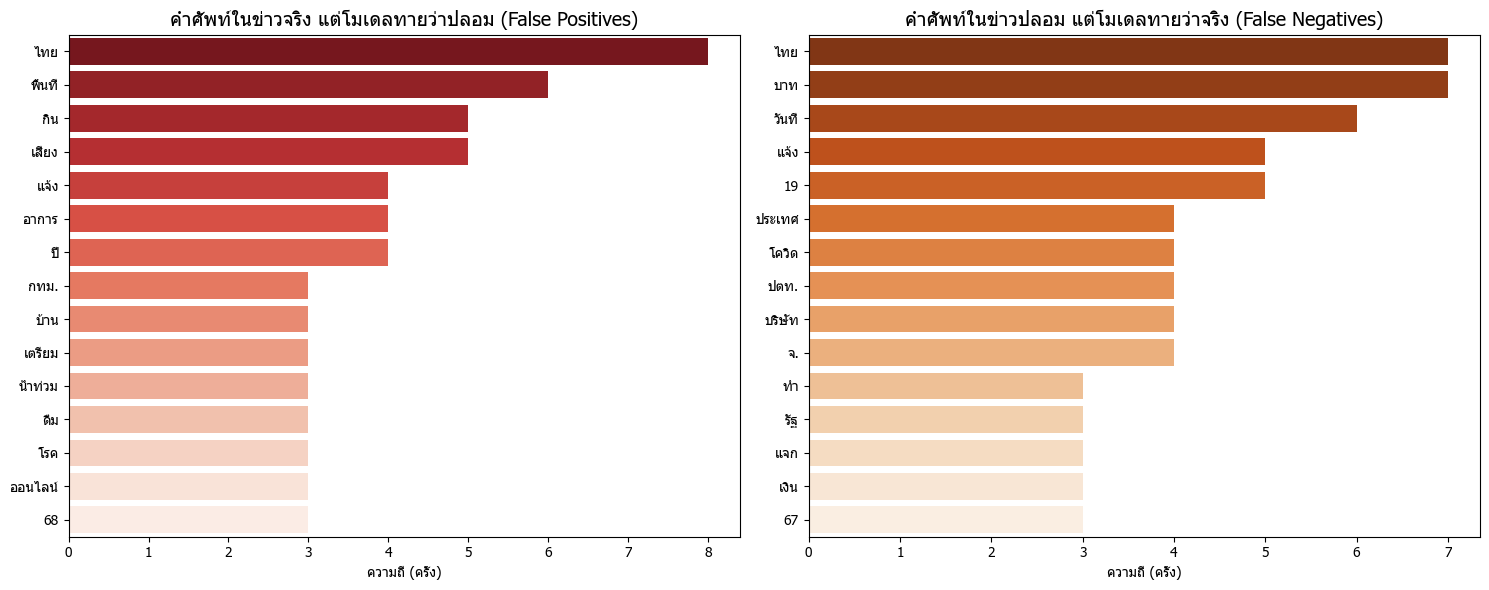

In [22]:
# ====================================================================
# PART 6 — Keyword Analysis for Misclassified News
# ====================================================================
from pythainlp.corpus import thai_stopwords

print("\n" + "="*80)
print("📊 KEYWORD ANALYSIS: คำศัพท์ที่มักทำให้โมเดลทายผิด")
print("="*80)

stopwords_set = set(thai_stopwords())
custom_sw     = {' ', '\n', '(', ')', '"', "'", '!', '?', '-', '"', '"',
                 ':', '/', 'ๆ', 'ได้', 'ที่', 'ใน', 'การ', 'และ', 'เป็น',
                 'มี', 'ให้', 'ของ', 'จะ', 'ว่า'}
all_stopwords = stopwords_set.union(custom_sw)

def get_top_keywords(news_list, top_n=15):
    all_words = []
    for item in news_list:
        words = word_tokenize(str(item['text']), engine='newmm', keep_whitespace=False)
        all_words.extend([w for w in words if w not in all_stopwords and len(w) > 1])
    return Counter(all_words).most_common(top_n)              

fp_news = [item for item in misclassified_samples if "False Positive"  in item['error_type']]
fn_news = [item for item in misclassified_samples if "False Negative" in item['error_type']]

top_fp_words = get_top_keywords(fp_news,  top_n=15)
top_fn_words = get_top_keywords(fn_news, top_n=15)

print("📌 Top 15 คำ — False Positives (ข่าวจริงที่โมเดลคิดว่าปลอม):")
for word, count in top_fp_words:
    print(f"   - {word}: {count} ครั้ง")

print("\n📌 Top 15 คำ — False Negatives (ข่าวปลอมที่โมเดลคิดว่าจริง):")
for word, count in top_fn_words:
    print(f"   - {word}: {count} ครั้ง")

if top_fp_words and top_fn_words:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    words_fp, counts_fp = zip(*top_fp_words)
    sns.barplot(x=list(counts_fp), y=list(words_fp), ax=axes[0], palette='Reds_r')
    axes[0].set_title('คำศัพท์ในข่าวจริง แต่โมเดลทายว่าปลอม (False Positives)', fontsize=14)
    axes[0].set_xlabel('ความถี่ (ครั้ง)')

    words_fn, counts_fn = zip(*top_fn_words)
    sns.barplot(x=list(counts_fn), y=list(words_fn), ax=axes[1], palette='Oranges_r')
    axes[1].set_title('คำศัพท์ในข่าวปลอม แต่โมเดลทายว่าจริง (False Negatives)', fontsize=14)
    axes[1].set_xlabel('ความถี่ (ครั้ง)')

    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ ไม่พบข้อมูลคำศัพท์เพียงพอ (โมเดลอาจทายถูกเกือบหมด!)")


In [23]:
# ====================================================================
# PART 7 — Cross-Model Error Analysis
# ====================================================================
print("\n" + "="*80)
print("🕵️‍♂️ CROSS-MODEL ERROR ANALYSIS")
print("="*80)

df_errors_all = pd.DataFrame({
    'text':       test_texts,
    'true_label': y_test_base,
    'pred_gcn':   y_pred_gcn,
    'pred_wcb':   y_pred_wcb_rf,
    'pred_xlm':   y_pred_xlm,
    'pred_tfidf': y_pred_tfidf,
})
df_errors_all['true_label_text'] = df_errors_all['true_label'].map(id2label)

df_errors_all['gcn_wrong']   = df_errors_all['true_label'] != df_errors_all['pred_gcn']
df_errors_all['wcb_wrong']   = df_errors_all['true_label'] != df_errors_all['pred_wcb']
df_errors_all['xlm_wrong']   = df_errors_all['true_label'] != df_errors_all['pred_xlm']
df_errors_all['tfidf_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_tfidf']

df_errors_all['num_models_wrong'] = (
    df_errors_all['gcn_wrong'].astype(int) +
    df_errors_all['wcb_wrong'].astype(int) +
    df_errors_all['xlm_wrong'].astype(int) +
    df_errors_all['tfidf_wrong'].astype(int)
)

def get_error_type(true_label):
    return "False Positive (จริงแต่ทายปลอม)" if true_label == 0 else "False Negative (ปลอมแต่ทายจริง)"

df_errors_all['error_type'] = df_errors_all['true_label'].apply(get_error_type)

all_wrong_df        = df_errors_all[df_errors_all['num_models_wrong'] == 4]
gcn_only_correct_df = df_errors_all[(df_errors_all['num_models_wrong'] == 3) & (~df_errors_all['gcn_wrong'])]

print(f"📊 จากข้อมูลทดสอบ {len(df_errors_all)} ข่าว:")
print(f"  - ทายผิดทั้ง 4 โมเดล (Hard Examples): {len(all_wrong_df)} ข่าว")
print(f"  - GCN ทายถูกตัวเดียว: {len(gcn_only_correct_df)} ข่าว")

show_n = min(10, len(all_wrong_df))
print(f"\n🚨 ตัวอย่างข่าว Hard Examples ({show_n} ข่าว):")
for idx, row in all_wrong_df.head(show_n).iterrows():
    print(f"\n[{idx}] ❌ {row['error_type']}")
    print(f"เนื้อหา : {row['text']}")
    print(f"-> ความเป็นจริงคือ: {row['true_label_text']}")
    print("-" * 60)


🕵️‍♂️ CROSS-MODEL ERROR ANALYSIS
📊 จากข้อมูลทดสอบ 862 ข่าว:
  - ทายผิดทั้ง 4 โมเดล (Hard Examples): 16 ข่าว
  - GCN ทายถูกตัวเดียว: 14 ข่าว

🚨 ตัวอย่างข่าว Hard Examples (10 ข่าว):

[3] ❌ False Negative (ปลอมแต่ทายจริง)
เนื้อหา :  วันที่ 13-15 พ.ย. 67 พายุลูกใหม่กำลังจะเข้าภาคอีสานตอนล่าง
-> ความเป็นจริงคือ: ข่าวปลอม
------------------------------------------------------------

[36] ❌ False Positive (จริงแต่ทายปลอม)
เนื้อหา : อาการเจ็บหน้าอก สัญญาณอันตรายที่ไม่ควรมองข้าม
-> ความเป็นจริงคือ: ข่าวจริง
------------------------------------------------------------

[212] ❌ False Positive (จริงแต่ทายปลอม)
เนื้อหา : ทุเรียน ลิ้นจี่ มะม่วง ลำไย และกล้วยสุก กินเยอะเสี่ยงเป็นเบาหวาน
-> ความเป็นจริงคือ: ข่าวจริง
------------------------------------------------------------

[360] ❌ False Positive (จริงแต่ทายปลอม)
เนื้อหา : กระทรวงดีอี เร่งปลดล็อกบัญชีชั่วคราว ให้ประชาชนที่ได้รับโอนเงินอย่างสุจริต
-> ความเป็นจริงคือ: ข่าวจริง
------------------------------------------------------------

[362] ❌ Fa

In [24]:
# ====================================================================
# PART 8 — Individual Model Error Analysis
# ====================================================================
print("\n" + "="*80)
print("🔍 INDIVIDUAL ERROR ANALYSIS")
print("="*80)

models_list = [
    ("1. GCN (Wangchan+Graph)", y_pred_gcn),
    ("2. TF-IDF + LR",          y_pred_tfidf),
    ("3. WangchanBERTa + RF",   y_pred_wcb_rf),
    ("4. XLM-RoBERTa + LR",    y_pred_xlm),
]
num_to_show = 3

for model_name, y_pred in models_list:
    fp_list = []
    fn_list = []

    for i in range(len(y_test_base)):
        true_lbl = y_test_base[i]
        pred_lbl = y_pred[i]
        if true_lbl != pred_lbl:
            error_data = {
                'text':            test_texts[i],
                'true_label_text': id2label[true_lbl],
                'pred_label_text': id2label[pred_lbl],
            }
            if pred_lbl == 1:
                fp_list.append(error_data)
            else:
                fn_list.append(error_data)

    print(f"\n" + "-"*60)
    print(f"🤖 โมเดล: {model_name}")
    print(f"   ทายผิดทั้งหมด: {len(fp_list) + len(fn_list)} ข่าว (FP: {len(fp_list)}, FN: {len(fn_list)})")
    print("-" * 60)

    print(f"  🔻 False Positives (จริง → ทายปลอม):")
    for i, item in enumerate(fp_list[:num_to_show]):
        print(f"     [{i+1}] {item['text']}")
    if not fp_list:
        print("     (ไม่มีทายผิดในกลุ่มนี้ 🎉)")

    print(f"\n  🔺 False Negatives (ปลอม → ทายจริง):")
    for i, item in enumerate(fn_list[:num_to_show]):
        print(f"     [{i+1}] {item['text']}")
    if not fn_list:
        print("     (ไม่มีทายผิดในกลุ่มนี้ 🎉)")

print("\n" + "="*80)
print("✅ Pipeline complete.")
print("="*80)


🔍 INDIVIDUAL ERROR ANALYSIS

------------------------------------------------------------
🤖 โมเดล: 1. GCN (Wangchan+Graph)
   ทายผิดทั้งหมด: 449 ข่าว (FP: 234, FN: 215)
------------------------------------------------------------
  🔻 False Positives (จริง → ทายปลอม):
     [1] สหรัฐตั้งคณะทำงานกับไทย เพื่อศึกษาการสร้างโรงงานชิปในไทย จริงหรือ?
     [2] บขส. เตรียมรถวันละ 3,700 เที่ยว รองรับคนเดินทางกลับบ้านช่วงสงกรานต์ และไม่มีนโยบายปรับขึ้นราคาค่าโดยสาร จริงหรือ?
     [3] ครม. อนุมัติ 2 พันล้านบาท ให้กองทุนฟื้นฟู และพัฒนาเกษตรกร จริงหรือ?

  🔺 False Negatives (ปลอม → ทายจริง):
     [1]  ธ.กรุงไทยเปิดสินเชื่อส่วนบุคคล กู้ได้ทุกอาชีพ ไม่ต้องใช้หลักทรัพย์ค้ำประกัน
     [2]  ธ.กรุงไทย ให้ยืมเงินปิดหนี้ตามนโยบายรัฐ ดอกเบี้ยต่ำ ได้ทุกอาชีพ 50,000 - 200,000 บาท
     [3]  วันที่ 13-15 พ.ย. 67 พายุลูกใหม่กำลังจะเข้าภาคอีสานตอนล่าง

------------------------------------------------------------
🤖 โมเดล: 2. TF-IDF + LR
   ทายผิดทั้งหมด: 63 ข่าว (FP: 51, FN: 12)
-------------------------------------

C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:114: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Tahoma.
  plt.tight_layout()
C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:114: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Tahoma.
  plt.tight_layout()
C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:114: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Tahoma.
  plt.tight_layout()
C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:114: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Tahoma.
  plt.tight_layout()
C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:115: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Tahoma.
  plt.savefig("plot1_overview_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:115: UserWarning: Glyph

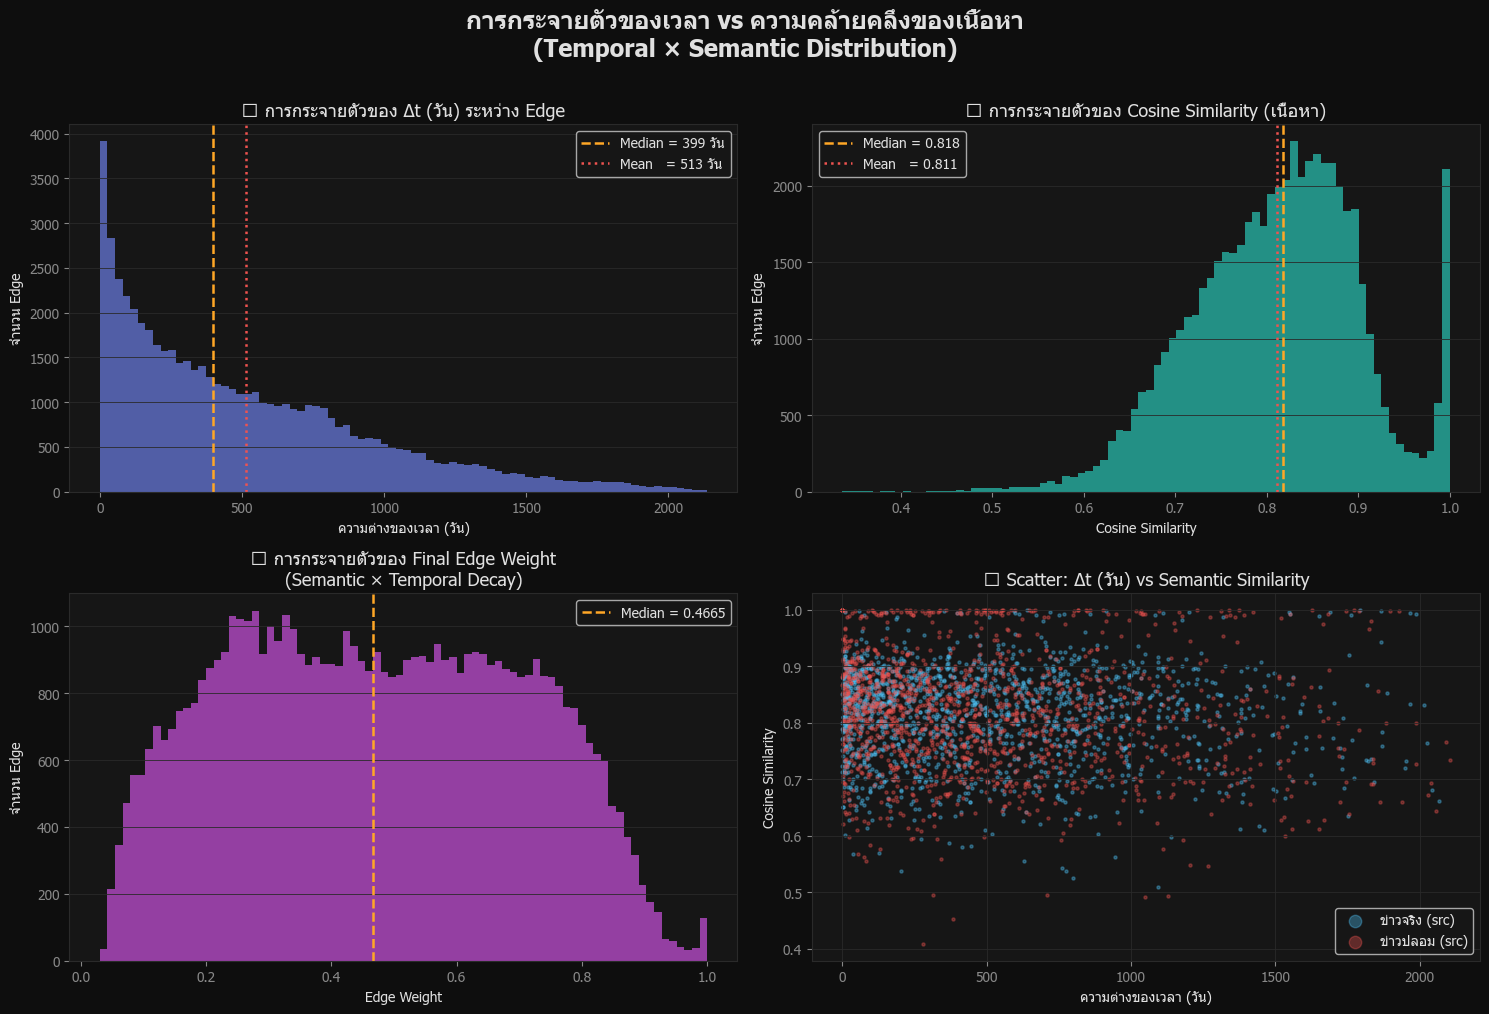

✅ บันทึก plot1_overview_dashboard.png


C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:139: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) Tahoma.
  plt.tight_layout()
C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:140: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) Tahoma.
  plt.savefig("plot2_kde_true_vs_fake.png", dpi=150, bbox_inches="tight", facecolor=BG)
c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


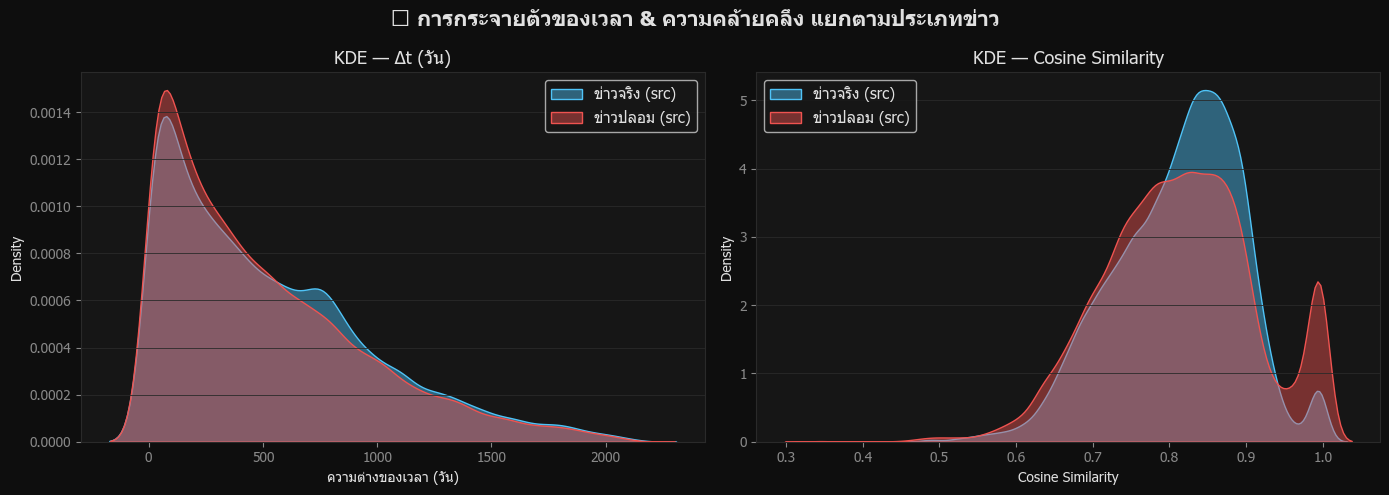

C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:164: UserWarning: Glyph 9317 (\N{CIRCLED DIGIT SIX}) missing from font(s) Tahoma.
  plt.tight_layout()


✅ บันทึก plot2_kde_true_vs_fake.png


C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:165: UserWarning: Glyph 9317 (\N{CIRCLED DIGIT SIX}) missing from font(s) Tahoma.
  plt.savefig("plot3_hexbin_density.png", dpi=150, bbox_inches="tight", facecolor=BG)
c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9317 (\N{CIRCLED DIGIT SIX}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


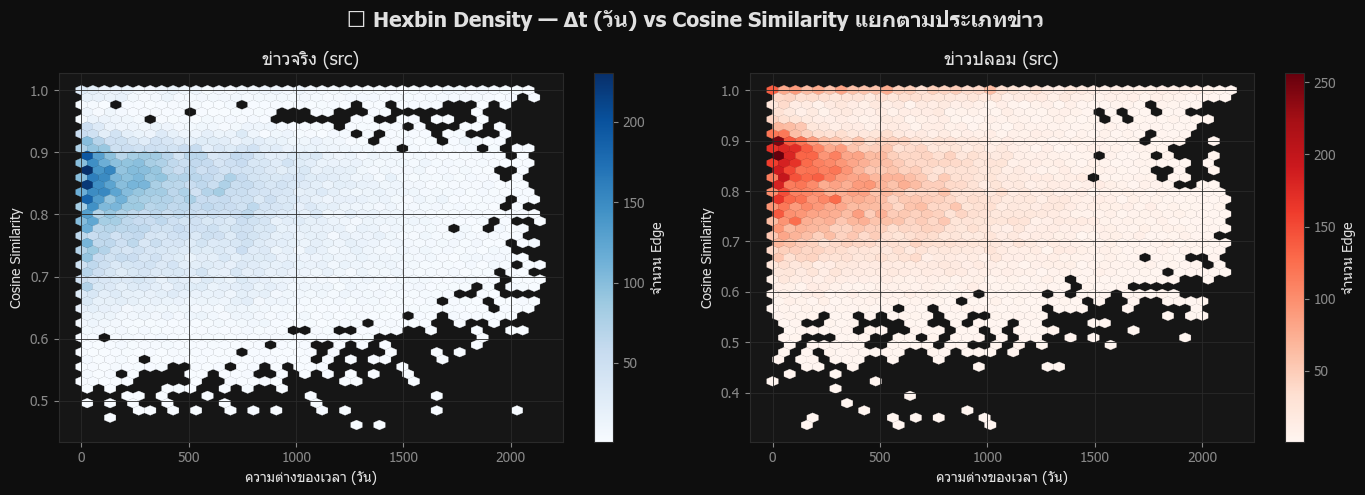

✅ บันทึก plot3_hexbin_density.png


c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9318 (\N{CIRCLED DIGIT SEVEN}) missing from font(s) Tahoma.
  fig.canvas.draw()
C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:197: UserWarning: Glyph 9318 (\N{CIRCLED DIGIT SEVEN}) missing from font(s) Tahoma.
  plt.savefig("plot4_heatmap_weight.png", dpi=150, bbox_inches="tight", facecolor=BG)
c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9318 (\N{CIRCLED DIGIT SEVEN}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


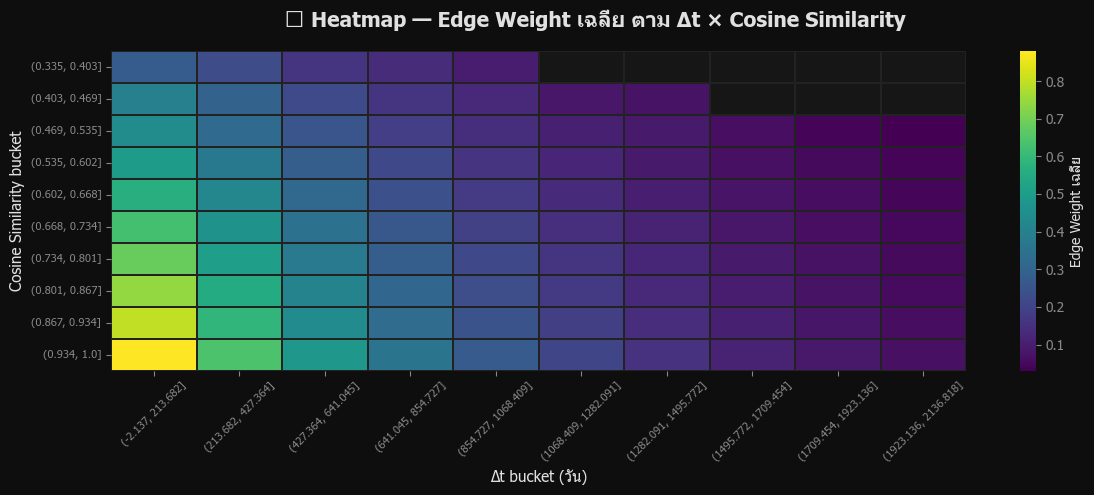

C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:232: UserWarning: Glyph 9319 (\N{CIRCLED DIGIT EIGHT}) missing from font(s) Tahoma.
  plt.tight_layout()


✅ บันทึก plot4_heatmap_weight.png


C:\Users\Infinix\AppData\Local\Temp\ipykernel_1308\2377533097.py:233: UserWarning: Glyph 9319 (\N{CIRCLED DIGIT EIGHT}) missing from font(s) Tahoma.
  plt.savefig("plot5_decay_curve.png", dpi=150, bbox_inches="tight", facecolor=BG)
c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9319 (\N{CIRCLED DIGIT EIGHT}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


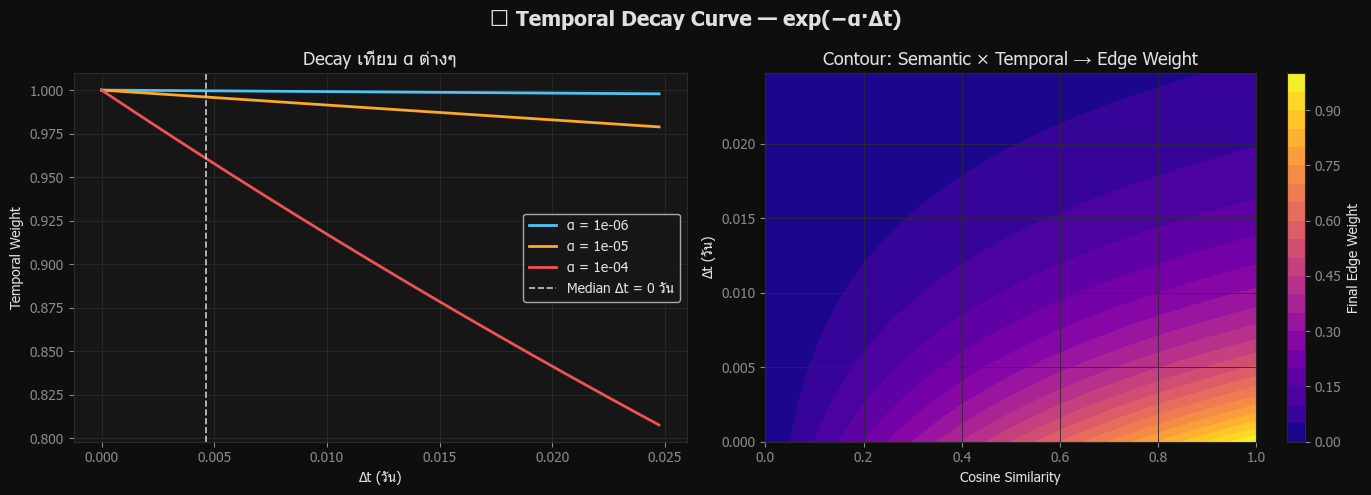

✅ บันทึก plot5_decay_curve.png

📊 EDGE STATISTICS SUMMARY
  Δt เฉลี่ย (วัน)             : 512.9
  Δt median (วัน)             : 399.1
  Δt สูงสุด (วัน)             : 2136.8
  Cosine Sim เฉลี่ย           : 0.8113
  Cosine Sim median           : 0.8179
  Edge Weight เฉลี่ย          : 0.4718
  Edge Weight median          : 0.4665
  จำนวน Edge ทั้งหมด          : 57,440


In [25]:
# ====================================================================
# PLOT: การกระจายตัวของเวลา vs ความคล้ายคลึงของเนื้อหา
# ต้องรันหลังจาก Section 9 (Build Temporal Graph) เสร็จแล้ว
# ตัวแปรที่ต้องมี: edges, weights, time_values, x_balanced,
#                  distances, indices, y_balanced, k, N_balanced
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

try:
    plt.rcParams['font.family'] = 'Tahoma'
except Exception:
    pass

# ── รวบรวม edge-level stats ──────────────────────────────────────────
edges_arr   = np.array(edges)           # (E, 2)
weights_arr = np.array(weights)         # (E,)

src = edges_arr[:, 0]
dst = edges_arr[:, 1]

sem_sim   = np.array([1 - distances[i][j_idx]
                       for i in range(N_balanced)
                       for j_idx in range(1, k + 1)])

dt_seconds = np.array([abs(int(time_values[i]) - int(time_values[edges_arr[e, 1]]))
                        for e, i in enumerate(src)])

dt_days    = dt_seconds / 86400          # แปลงเป็นวัน
label_src  = y_balanced[src]             # label ของ source node

# ── สี ───────────────────────────────────────────────────────────────
C_TRUE  = "#4FC3F7"   # ข่าวจริง  — ฟ้าอ่อน
C_FAKE  = "#EF5350"   # ข่าวปลอม — แดง
C_EDGE  = "#AB47BC"   # edge weight — ม่วง
BG      = "#0E0E0E"
PANEL   = "#161616"
GRID    = "#2a2a2a"
TEXT    = "#E0E0E0"
MUTED   = "#888888"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        TEXT,
    "grid.color":        GRID,
    "grid.linewidth":    0.6,
})

# ====================================================================
# FIGURE 1 — 2×2 Overview Dashboard
# ====================================================================
fig1, axes = plt.subplots(2, 2, figsize=(15, 10))
fig1.suptitle("การกระจายตัวของเวลา vs ความคล้ายคลึงของเนื้อหา\n(Temporal × Semantic Distribution)",
              fontsize=17, fontweight="bold", color=TEXT, y=1.01)

ax = axes[0, 0]
ax.hist(dt_days, bins=80, color="#5C6BC0", edgecolor="none", alpha=0.85)
ax.set_title("① การกระจายตัวของ Δt (วัน) ระหว่าง Edge", fontsize=13, color=TEXT)
ax.set_xlabel("ความต่างของเวลา (วัน)", color=TEXT)
ax.set_ylabel("จำนวน Edge", color=TEXT)
ax.axvline(np.median(dt_days), color="#FFA726", lw=1.8, ls="--",
           label=f"Median = {np.median(dt_days):.0f} วัน")
ax.axvline(np.mean(dt_days),   color="#EF5350", lw=1.8, ls=":",
           label=f"Mean   = {np.mean(dt_days):.0f} วัน")
ax.legend(fontsize=10); ax.grid(True, axis="y")

ax = axes[0, 1]
ax.hist(sem_sim, bins=80, color="#26A69A", edgecolor="none", alpha=0.85)
ax.set_title("② การกระจายตัวของ Cosine Similarity (เนื้อหา)", fontsize=13, color=TEXT)
ax.set_xlabel("Cosine Similarity", color=TEXT)
ax.set_ylabel("จำนวน Edge", color=TEXT)
ax.axvline(np.median(sem_sim), color="#FFA726", lw=1.8, ls="--",
           label=f"Median = {np.median(sem_sim):.3f}")
ax.axvline(np.mean(sem_sim),   color="#EF5350", lw=1.8, ls=":",
           label=f"Mean   = {np.mean(sem_sim):.3f}")
ax.legend(fontsize=10); ax.grid(True, axis="y")

ax = axes[1, 0]
ax.hist(weights_arr, bins=80, color=C_EDGE, edgecolor="none", alpha=0.85)
ax.set_title("③ การกระจายตัวของ Final Edge Weight\n(Semantic × Temporal Decay)", fontsize=13, color=TEXT)
ax.set_xlabel("Edge Weight", color=TEXT)
ax.set_ylabel("จำนวน Edge", color=TEXT)
ax.axvline(np.median(weights_arr), color="#FFA726", lw=1.8, ls="--",
           label=f"Median = {np.median(weights_arr):.4f}")
ax.legend(fontsize=10); ax.grid(True, axis="y")

ax = axes[1, 1]
# Scatter: Δt vs Semantic Similarity, coloured by label
mask_true = label_src == 0
mask_fake = label_src == 1
sample = min(3000, len(dt_days))   # จำกัดจุดเพื่อความเร็ว
rng    = np.random.default_rng(42)
idx_s  = rng.choice(len(dt_days), sample, replace=False)

ax.scatter(dt_days[idx_s][mask_true[idx_s]], sem_sim[idx_s][mask_true[idx_s]],
           s=5, alpha=0.35, color=C_TRUE, label="ข่าวจริง (src)")
ax.scatter(dt_days[idx_s][mask_fake[idx_s]], sem_sim[idx_s][mask_fake[idx_s]],
           s=5, alpha=0.35, color=C_FAKE, label="ข่าวปลอม (src)")
ax.set_title("④ Scatter: Δt (วัน) vs Semantic Similarity", fontsize=13, color=TEXT)
ax.set_xlabel("ความต่างของเวลา (วัน)", color=TEXT)
ax.set_ylabel("Cosine Similarity", color=TEXT)
ax.legend(fontsize=10, markerscale=4); ax.grid(True)

plt.tight_layout()
plt.savefig("plot1_overview_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ บันทึก plot1_overview_dashboard.png")

# ====================================================================
# FIGURE 2 — KDE Overlay: จริง vs ปลอม แยก Δt และ Similarity
# ====================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("⑤ การกระจายตัวของเวลา & ความคล้ายคลึง แยกตามประเภทข่าว",
              fontsize=15, fontweight="bold", color=TEXT)

for ax, data_t, data_f, xlabel, title in [
    (axes2[0], dt_days[mask_true],  dt_days[mask_fake],
     "ความต่างของเวลา (วัน)",    "KDE — Δt (วัน)"),
    (axes2[1], sem_sim[mask_true], sem_sim[mask_fake],
     "Cosine Similarity",          "KDE — Cosine Similarity"),
]:
    sns.kdeplot(data_t, ax=ax, fill=True, color=C_TRUE, alpha=0.45, label="ข่าวจริง (src)")
    sns.kdeplot(data_f, ax=ax, fill=True, color=C_FAKE, alpha=0.45, label="ข่าวปลอม (src)")
    ax.set_title(title, fontsize=13, color=TEXT)
    ax.set_xlabel(xlabel, color=TEXT)
    ax.set_ylabel("Density", color=TEXT)
    ax.legend(fontsize=11); ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("plot2_kde_true_vs_fake.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ บันทึก plot2_kde_true_vs_fake.png")

# ====================================================================
# FIGURE 3 — 2D Hexbin: Δt vs Semantic Similarity (density)
# ====================================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle("⑥ Hexbin Density — Δt (วัน) vs Cosine Similarity แยกตามประเภทข่าว",
              fontsize=15, fontweight="bold", color=TEXT)

for ax, mask, title, cmap in [
    (axes3[0], mask_true, "ข่าวจริง (src)", "Blues"),
    (axes3[1], mask_fake, "ข่าวปลอม (src)", "Reds"),
]:
    hb = ax.hexbin(dt_days[mask], sem_sim[mask],
                   gridsize=40, cmap=cmap, mincnt=1,
                   linewidths=0.2)
    plt.colorbar(hb, ax=ax, label="จำนวน Edge")
    ax.set_title(title, fontsize=13, color=TEXT)
    ax.set_xlabel("ความต่างของเวลา (วัน)", color=TEXT)
    ax.set_ylabel("Cosine Similarity", color=TEXT)
    ax.grid(True)

plt.tight_layout()
plt.savefig("plot3_hexbin_density.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ บันทึก plot3_hexbin_density.png")

# ====================================================================
# FIGURE 4 — Edge Weight Heatmap: Δt bucket vs Similarity bucket
# ====================================================================
fig4, ax4 = plt.subplots(figsize=(12, 5))
fig4.suptitle("⑦ Heatmap — Edge Weight เฉลี่ย ตาม Δt × Cosine Similarity",
              fontsize=15, fontweight="bold", color=TEXT)

n_bins   = 10
dt_cut   = pd.cut(dt_days,  bins=n_bins)
sim_cut  = pd.cut(sem_sim,  bins=n_bins)

df_heat  = pd.DataFrame({
    "dt_bin":  dt_cut,
    "sim_bin": sim_cut,
    "weight":  weights_arr,
})
pivot = df_heat.groupby(["sim_bin", "dt_bin"], observed=True)["weight"].mean().unstack()

sns.heatmap(pivot, ax=ax4, cmap="viridis",
            linewidths=0.3, linecolor="#222",
            cbar_kws={"label": "Edge Weight เฉลี่ย"})
ax4.set_title("", fontsize=12)
ax4.set_xlabel("Δt bucket (วัน)", color=TEXT, fontsize=11)
ax4.set_ylabel("Cosine Similarity bucket", color=TEXT, fontsize=11)
ax4.tick_params(axis="x", rotation=45, labelsize=8)
ax4.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig("plot4_heatmap_weight.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ บันทึก plot4_heatmap_weight.png")

# ====================================================================
# FIGURE 5 — Temporal Decay Curve (ทฤษฎี)
# ====================================================================
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5))
fig5.suptitle("⑧ Temporal Decay Curve — exp(−α·Δt)",
              fontsize=15, fontweight="bold", color=TEXT)

dt_range = np.linspace(0, dt_days.max(), 500)

ax = axes5[0]
for a, color in [(0.000001, "#4FC3F7"), (0.00001, "#FFA726"), (0.0001, "#EF5350")]:
    ax.plot(dt_range / 86400, np.exp(-a * dt_range),
            label=f"α = {a:.0e}", lw=2, color=color)
ax.axvline(np.median(dt_days / 86400), color="#ccc", lw=1.2, ls="--",
           label=f"Median Δt = {np.median(dt_days/86400):.0f} วัน")
ax.set_title("Decay เทียบ α ต่างๆ", fontsize=13, color=TEXT)
ax.set_xlabel("Δt (วัน)", color=TEXT); ax.set_ylabel("Temporal Weight", color=TEXT)
ax.legend(fontsize=10); ax.grid(True)

ax = axes5[1]
sim_range = np.linspace(0, 1, 200)
dt_range2 = np.linspace(0, dt_days.max(), 200)
SIM, DT   = np.meshgrid(sim_range, dt_range2)
W         = SIM * np.exp(-alpha * DT)
cp = ax.contourf(SIM, DT / 86400, W, levels=20, cmap="plasma")
plt.colorbar(cp, ax=ax, label="Final Edge Weight")
ax.set_title("Contour: Semantic × Temporal → Edge Weight", fontsize=13, color=TEXT)
ax.set_xlabel("Cosine Similarity", color=TEXT)
ax.set_ylabel("Δt (วัน)", color=TEXT)
ax.grid(True)

plt.tight_layout()
plt.savefig("plot5_decay_curve.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ บันทึก plot5_decay_curve.png")

# ====================================================================
# SUMMARY STATS
# ====================================================================
print("\n" + "="*60)
print("📊 EDGE STATISTICS SUMMARY")
print("="*60)
stats = {
    "Δt เฉลี่ย (วัน)":          f"{np.mean(dt_days):.1f}",
    "Δt median (วัน)":          f"{np.median(dt_days):.1f}",
    "Δt สูงสุด (วัน)":          f"{np.max(dt_days):.1f}",
    "Cosine Sim เฉลี่ย":        f"{np.mean(sem_sim):.4f}",
    "Cosine Sim median":         f"{np.median(sem_sim):.4f}",
    "Edge Weight เฉลี่ย":       f"{np.mean(weights_arr):.4f}",
    "Edge Weight median":        f"{np.median(weights_arr):.4f}",
    "จำนวน Edge ทั้งหมด":       f"{len(weights_arr):,}",
}
for k_s, v_s in stats.items():
    print(f"  {k_s:<28}: {v_s}")
print("="*60)

In [26]:
print(df_balanced['วันและเวลาที่เผยแพร่'].head(5)) # ดูข้อมูลดิบ
print(publish_dates.head(5)) # ดูข้อมูลที่แปลงแล้ว

0    03/05/2567 09:00:53
1    03/04/2564 03:01:50
2    11/07/2568 03:30:59
3    07/11/2567 09:30:39
4    24/06/2566 09:30:52
Name: วันและเวลาที่เผยแพร่, dtype: object
0   2024-05-03 09:00:53
1   2021-04-03 03:01:50
2   2025-07-11 03:30:59
3   2024-11-07 09:30:39
4   2023-06-24 09:30:52
Name: วันและเวลาที่เผยแพร่, dtype: datetime64[ns]
